In [1]:
# auto reload
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

from selfrf.utils.visualizer import visualize_batch
from selfrf.pretraining.factories import build_dataloader
from selfrf.pretraining.config import TrainingConfig
from selfrf.pretraining.utils.enums import DatasetType, SSLModelType

0it [00:00, ?it/s]

In [3]:
ROOT = Path("../datasets")

# BYOL

In [32]:
byol_wideband_config = TrainingConfig(
    root=ROOT,
    dataset=DatasetType.TORCHSIG_WIDEBAND,
    spectrogram=True,
    ssl_model=SSLModelType.BYOL,
    num_workers=0,
    batch_size=1,
    nfft=512,
)

byol_narrowband_config = TrainingConfig(
    root=ROOT ,
    dataset=DatasetType.IQDM_NARROWBAND,
    spectrogram=True,
    ssl_model=SSLModelType.BYOL,
    num_workers=0,
    batch_size=4,
    nfft=128,
    num_samples=300,
)

Wideband

In [5]:
datamodule = build_dataloader(byol_wideband_config)
datamodule.prepare_data()
datamodule.setup("fit")

Train Dataset: Wideband, Impairment Level 2, 5000 samples
Dataset exists at ../datasets/torchsig_wideband_impaired/train but is different than current dataset.
Differences:
	seed = 2025759928653977594 (404951623201600874 found)
If you want to overwrite dataset on disk, set overwrite = True for the DatasetCreator.
Not regenerating. Using dataset on disk.
Val Dataset: Wideband, Impairment Level 2, 500 samples




  3%|▎         | 2/63 [00:04<02:24,  2.36s/it]


KeyboardInterrupt: 

In [ ]:
loader = datamodule.train_dataloader()
batch = next(iter(loader))
visualize_batch(batch, mode="spectrogram")


Narrowband

In [33]:
print("🧠 SSL model:", type(byol_narrowband_config.ssl_model), byol_narrowband_config.ssl_model)

datamodule = build_dataloader(byol_narrowband_config)
print(f"🧪 Using DataModule: {type(datamodule)}")
print(f"🧪 Dataset type: {byol_narrowband_config.dataset}")
print(f"🧪 Dataset root path: {byol_narrowband_config.root}")

datamodule.prepare_data()

datamodule.setup("fit")

🧠 SSL model: <enum 'SSLModelType'> SSLModelType.BYOL
🧪 Using DataModule: <class 'selfrf.data.iqdm.iqdm_modules.IQDMNarrowbandDataModule'>
🧪 Dataset type: DatasetType.IQDM_NARROWBAND
🧪 Dataset root path: ../datasets


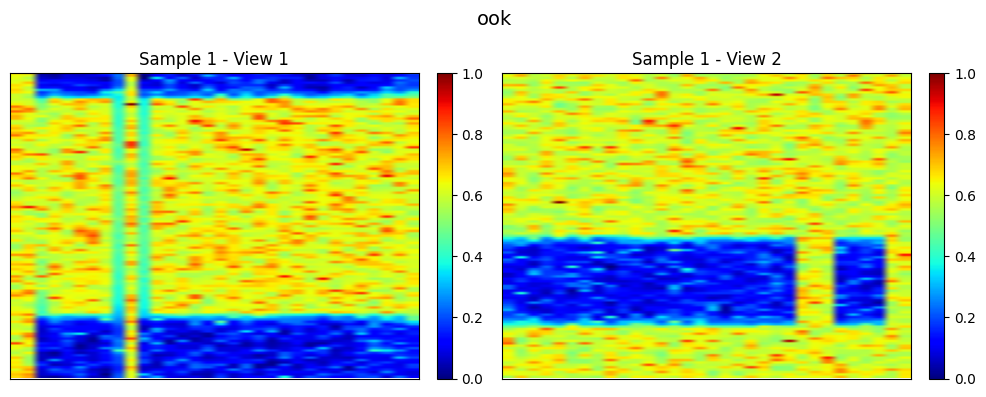

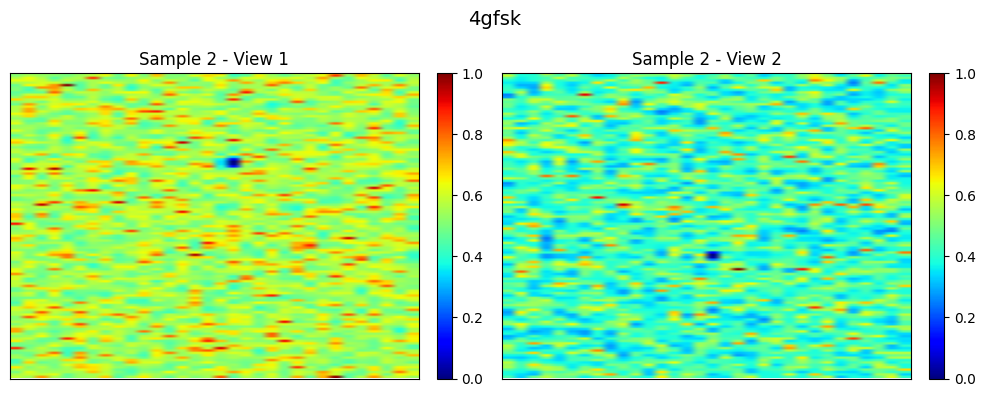

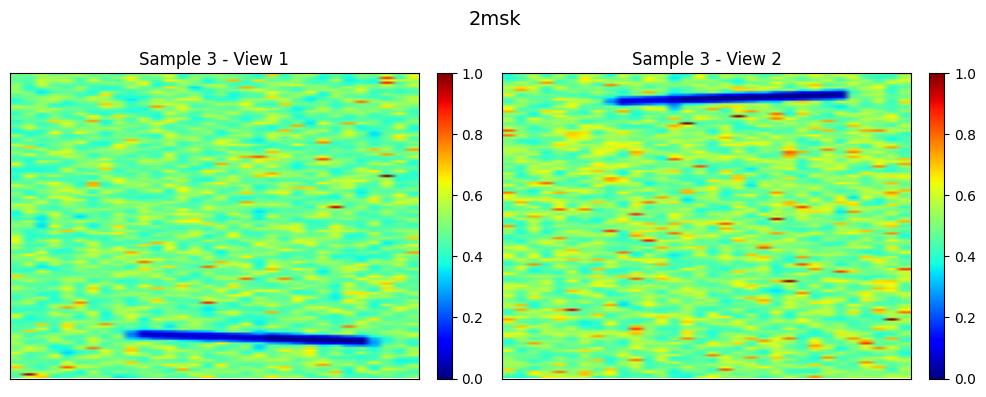

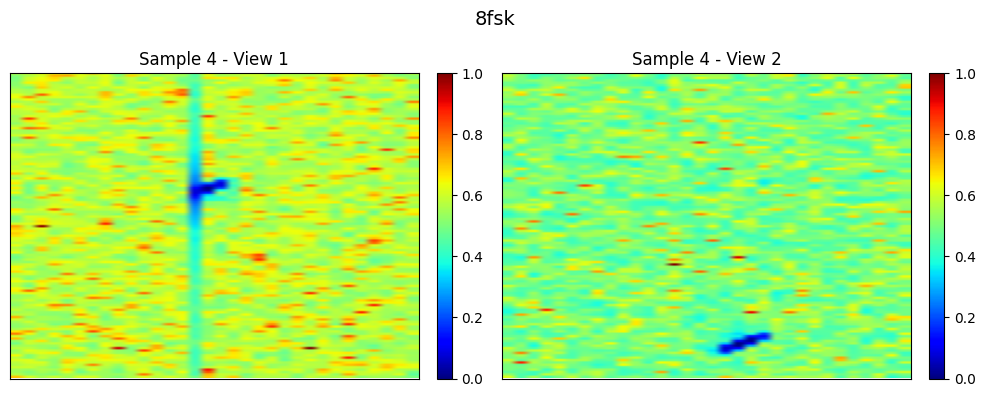

In [35]:
#datamodule.num_workers = 0
loader = datamodule.train_dataloader()
batch = next(iter(loader))
visualize_batch(batch, mode="spectrogram")

# DenseCL

In [ ]:
densecl_wideband_config = TrainingConfig(
    root=ROOT,
    dataset=DatasetType.TORCHSIG_WIDEBAND,
    download=False,
    spectrogram=True,
    ssl_model=SSLModelType.DENSECL,
    batch_size=2,
    nfft=512,
    num_samples=10,
)

densecl_narrowband_config = TrainingConfig(
    root=ROOT,
    dataset=DatasetType.TORCHSIG_NARROWBAND,
    download=True,
    spectrogram=True,
    ssl_model=SSLModelType.DENSECL,
    batch_size=2,
    nfft=256,
)

In [ ]:
datamodule = build_dataloader(densecl_wideband_config)
datamodule.prepare_data()
datamodule.setup("fit")

In [ ]:
visualize(10, datamodule.train_dataloader())

In [ ]:
datamodule = build_dataloader(densecl_narrowband_config)
datamodule.prepare_data()
datamodule.setup("fit")

In [ ]:
visualize(10, datamodule.train_dataloader())